In [1]:
## standard imports
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [2]:
from scipy.stats import uniform, norm, truncnorm, binom
from scipy.integrate import trapezoid

In [3]:
!pip install dynesty

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.9/102.9 kB 3.0 MB/s eta 0:00:00


In [4]:
from dynesty import NestedSampler

# Measure $p$

In [5]:
## consider three possible priors

## uniform
xmin = 0.0
xmax = 1.0
prior1 = uniform(loc=xmin, scale=xmax-xmin)

## truncated gaussian peaked in 0.5
loc = 0.5
scale = 0.15
xmin = 0.0
xmax = 1.0
a = (xmin - loc)/scale
b = (xmax - loc)/scale
prior2 = truncnorm(loc=loc,scale=scale,a=a,b=b)

## truncated gaussian peaked in 0.2
loc = 0.2
scale = 0.15
xmin = 0.0
xmax = 1.0
a = (xmin - loc)/scale
b = (xmax - loc)/scale
prior3 = truncnorm(loc=loc,scale=scale,a=a,b=b)

### Low number of coin tosses

In [6]:
## consider a fair coin and a single experiment consisting of 10 coin tosses
p_true = 0.5
n = 10
likelihood = binom(p=p_true,n=n)

In [9]:
## draw a random value of k
k = likelihood.rvs(size=1)
k

array([6])

In [10]:
## sample a fine grid of p
p_array = np.linspace(0,1,100)

## compute the log_likelihood
log_L = binom.logpmf(k=k,n=n,p=p_array)
L = np.exp(log_L)

## compute the log_prior
log_pi_1 = prior1.logpdf(p_array)
log_pi_2 = prior2.logpdf(p_array)
log_pi_3 = prior3.logpdf(p_array)

## compute the unnormalized posterior
log_P_1 = log_L + log_pi_1
log_P_2 = log_L + log_pi_2
log_P_3 = log_L + log_pi_3

P1 = np.exp(log_P_1)
P2 = np.exp(log_P_2)
P3 = np.exp(log_P_3)

## normalize the posterior
norm1 = trapezoid(y=P1, x=p_array)
norm2 = trapezoid(y=P2, x=p_array)
norm3 = trapezoid(y=P3, x=p_array)

P1 /= norm1
P2 /= norm2
P3 /= norm3

## conventionally normalize the likelihood
normL = trapezoid(y=L,x=p_array)
L /= normL

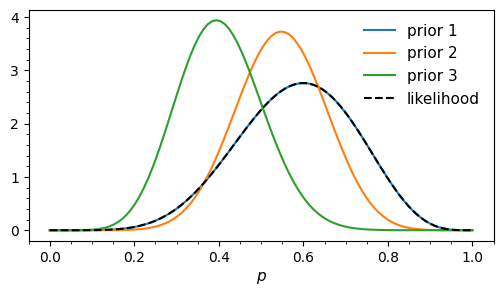

In [11]:
plt.figure(figsize=(6,3))

plt.plot(p_array,P1,label='prior 1')
plt.plot(p_array,P2,label='prior 2')
plt.plot(p_array,P3,label='prior 3')
plt.plot(p_array,L,label='likelihood',linestyle='--',color='k')

plt.xlabel(r'$p$',fontsize=11)

plt.minorticks_on()

plt.legend(fontsize=11,frameon=False)

plt.show()

### High number of coin tosses

In [12]:
## consider a fair coin and a single experiment consisting of 10 coin tosses
p_true = 0.5
n = 1000
likelihood = binom(p=p_true,n=n)

In [13]:
## draw a random value of k
k = likelihood.rvs(size=1)

In [14]:
## sample a fine grid of p
p_array = np.linspace(0,1,100)

## compute the log_likelihood
log_L = binom.logpmf(k=k,n=n,p=p_array)
L = np.exp(log_L)

## compute the log_prior
log_pi_1 = prior1.logpdf(p_array)
log_pi_2 = prior2.logpdf(p_array)
log_pi_3 = prior3.logpdf(p_array)

## compute the unnormalized posterior
log_P_1 = log_L + log_pi_1
log_P_2 = log_L + log_pi_2
log_P_3 = log_L + log_pi_3

P1 = np.exp(log_P_1)
P2 = np.exp(log_P_2)
P3 = np.exp(log_P_3)

## normalize the posterior
norm1 = trapezoid(y=P1, x=p_array)
norm2 = trapezoid(y=P2, x=p_array)
norm3 = trapezoid(y=P3, x=p_array)

P1 /= norm1
P2 /= norm2
P3 /= norm3

## conventionally normalize the likelihood
normL = trapezoid(y=L,x=p_array)
L /= normL

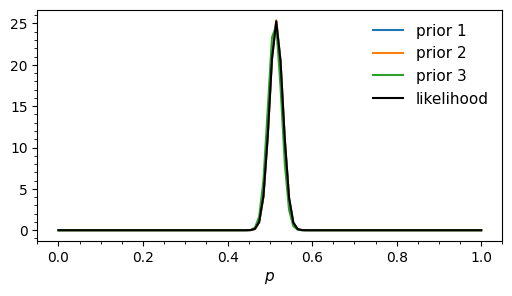

In [15]:
plt.figure(figsize=(6,3))

plt.plot(p_array,P1,label='prior 1')
plt.plot(p_array,P2,label='prior 2')
plt.plot(p_array,P3,label='prior 3')
plt.plot(p_array,L,label='likelihood',color='k')

plt.xlabel(r'$p$',fontsize=11)

plt.minorticks_on()

plt.legend(fontsize=11,frameon=False)

plt.show()

In [16]:
## the result suggest to sample p on a smaller domain
## sample a fine grid of p
p_array = np.linspace(0.4,0.6,100)

## compute the log_likelihood
log_L = binom.logpmf(k=k,n=n,p=p_array)
L = np.exp(log_L)

## compute the log_prior
log_pi_1 = prior1.logpdf(p_array)
log_pi_2 = prior2.logpdf(p_array)
log_pi_3 = prior3.logpdf(p_array)

## compute the unnormalized posterior
log_P_1 = log_L + log_pi_1
log_P_2 = log_L + log_pi_2
log_P_3 = log_L + log_pi_3

P1 = np.exp(log_P_1)
P2 = np.exp(log_P_2)
P3 = np.exp(log_P_3)

## normalize the posterior
norm1 = trapezoid(y=P1, x=p_array)
norm2 = trapezoid(y=P2, x=p_array)
norm3 = trapezoid(y=P3, x=p_array)

P1 /= norm1
P2 /= norm2
P3 /= norm3

## conventionally normalize the likelihood
normL = trapezoid(y=L,x=p_array)
L /= normL

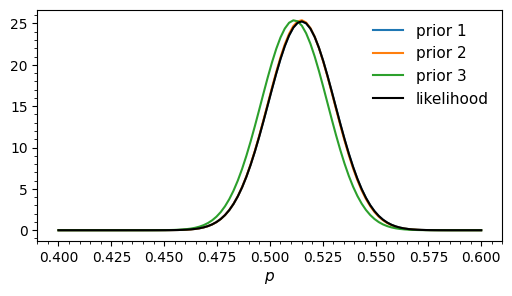

In [17]:
plt.figure(figsize=(6,3))

plt.plot(p_array,P1,label='prior 1')
plt.plot(p_array,P2,label='prior 2')
plt.plot(p_array,P3,label='prior 3')
plt.plot(p_array,L,label='likelihood',color='k')

plt.xlabel(r'$p$',fontsize=11)

plt.minorticks_on()

plt.legend(fontsize=11,frameon=False)

plt.show()

### sample with nested sampling

In [18]:
def ptform_1(u):
  xmin = 0.0
  xmax = 1.0
  x = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return x

def ptform_2(u):
  loc = 0.5
  scale = 0.15
  xmin = 0.0
  xmax = 1.0
  a = (xmin - loc)/scale
  b = (xmax - loc)/scale
  x = truncnorm.ppf(u,loc=loc,scale=scale,a=a,b=b)
  return x

def ptform_3(u):
  loc = 0.2
  scale = 0.15
  xmin = 0.0
  xmax = 1.0
  a = (xmin - loc)/scale
  b = (xmax - loc)/scale
  x = truncnorm.ppf(u,loc=loc,scale=scale,a=a,b=b)
  return x

In [19]:
def loglike(x):
  out = binom.logpmf(k=k,n=n,p=x)[0]
  return out

In [20]:
ndim = 1
nlive = 1000
sampler = NestedSampler(loglike, ptform_1, ndim, nlive=nlive)
sampler.run_nested()
res1 = sampler.results
samples1 = res1.samples_equal()

3663it [00:20, 178.53it/s, +1000 | bound: 1 | nc: 1 | ncall: 37125 | eff(%): 12.908 | loglstar:   -inf < -3.679 <    inf | logz: -6.959 +/-  0.029 | dlogz:  0.001 >  1.009]


In [21]:
ndim = 1
nlive = 1000
sampler = NestedSampler(loglike, ptform_2, ndim, nlive=nlive)
sampler.run_nested()
res2 = sampler.results
samples2 = res2.samples_equal()

2651it [00:10, 251.16it/s, +1000 | bound: 0 | nc: 1 | ncall: 15018 | eff(%): 26.045 | loglstar:   -inf < -3.679 <    inf | logz: -5.947 +/-    nan | dlogz:  0.001 >  1.009]


In [22]:
ndim = 1
nlive = 1000
sampler = NestedSampler(loglike, ptform_3, ndim, nlive=nlive)
sampler.run_nested()
res3 = sampler.results
samples3 = res3.samples_equal()

4708it [00:31, 151.54it/s, +1000 | bound: 2 | nc: 1 | ncall: 38362 | eff(%): 15.278 | loglstar:   -inf < -3.679 <    inf | logz: -8.006 +/-  0.043 | dlogz:  0.001 >  1.009]


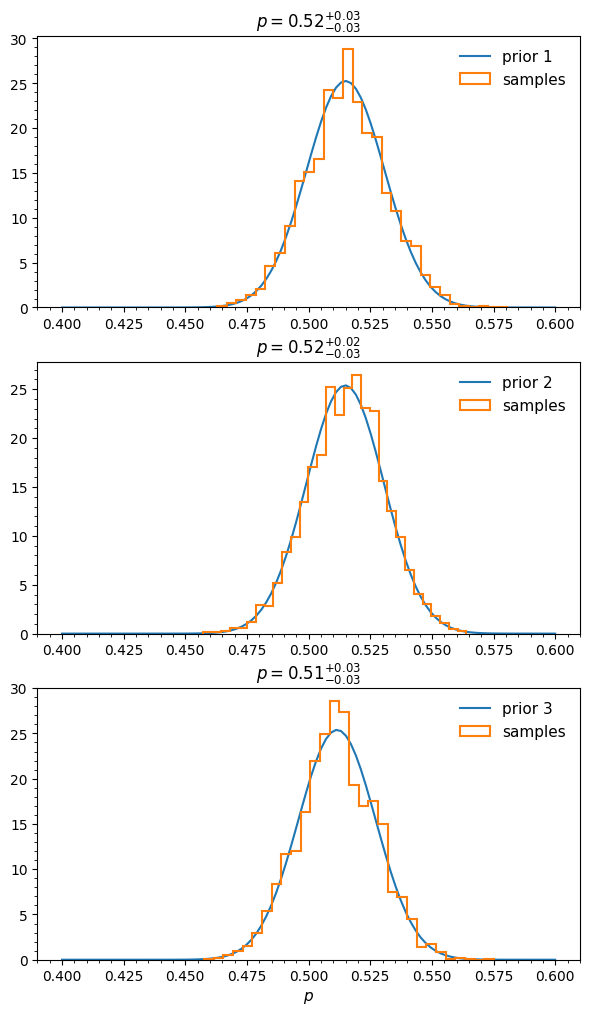

In [23]:
fig, axs = plt.subplots(3,1,figsize=(7,3*4))

axs[0].plot(p_array,P1,linewidth=1.5,label='prior 1')
axs[0].hist(samples1,bins=30,histtype='step',density=True,linewidth=1.5,label='samples')
a,b,c = np.quantile(samples1,q=[0.05,0.5,0.95])
axs[0].set_title(r'$p=%.2f^{+%.2f}_{%.2f}$'%(b,c-b,a-b),fontsize=12)

axs[1].plot(p_array,P2,label='prior 2')
axs[1].hist(samples2,bins=30,histtype='step',density=True,linewidth=1.5,label='samples')
a,b,c = np.quantile(samples2,q=[0.05,0.5,0.95])
axs[1].set_title(r'$p=%.2f^{+%.2f}_{%.2f}$'%(b,c-b,a-b),fontsize=12)

axs[2].plot(p_array,P3,label='prior 3')
axs[2].hist(samples3,bins=30,histtype='step',density=True,linewidth=1.5,label='samples')
a,b,c = np.quantile(samples3,q=[0.05,0.5,0.95])
axs[2].set_title(r'$p=%.2f^{+%.2f}_{%.2f}$'%(b,c-b,a-b),fontsize=12)

axs[2].set_xlabel(r'$p$',fontsize=11)

axs[0].minorticks_on()
axs[1].minorticks_on()
axs[2].minorticks_on()

axs[0].legend(fontsize=11,frameon=False)
axs[1].legend(fontsize=11,frameon=False)
axs[2].legend(fontsize=11,frameon=False)

plt.show()

# Multiple datasets

In [26]:
## consider a fair coin and a single experiment consisting of 10 coin tosses
p_true = 0.5
n = 2
likelihood = binom(p=p_true,n=n)

In [27]:
data = likelihood.rvs(size=100)

In [55]:
def ptform(u):
  p_est = data.mean()/n
  std = (p_est*(1-p_est)/n)**0.5
  xmin = max(0.0,p_est-5*std)
  xmax = min(1.0,p_est+5*std)
  x = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return x

def loglike(x):
  out = np.sum(binom.logpmf(k=data,n=n,p=x))
  return out

def loglike_norm(x):
  loc = n*x
  scale = (n*x*(1-x))**0.5
  if scale==0:
    return -np.inf
  xmin = 0
  xmax = n
  a = (xmin-loc)/scale
  b = (xmax-loc)/scale
  ## if you sample from non-truncated pdf:
  #out = np.sum(norm.logpdf(x=data,loc=loc,scale=scale))
  ## if you sample from truncated pdf:
  #out = np.sum(truncnorm.logpdf(x=data,loc=loc,scale=scale,a=a,b=b))
  ## if you sample from truncated pdf corrected to approximate a pmf:
  low = np.clip(data-0.5,xmin,xmax)
  high = np.clip(data+0.5,xmin,xmax)
  out = np.sum(np.log(truncnorm.cdf(x=high,loc=loc,scale=scale,a=a,b=b)-truncnorm.cdf(x=low,loc=loc,scale=scale,a=a,b=b)+1e-60))
  return out

In [51]:
ndim = 1
nlive = 5000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res = sampler.results
samples = res.samples_equal()

8734it [00:15, 566.57it/s, +5000 | bound: 0 | nc: 1 | ncall: 33879 | eff(%): 47.557 | loglstar:   -inf < -108.074 <    inf | logz: -110.489 +/-    nan | dlogz:  0.000 >  5.009]


In [56]:
sampler = NestedSampler(loglike_norm, ptform, ndim, nlive=nlive)
sampler.run_nested()
res_norm = sampler.results
samples_norm = res_norm.samples_equal()

7453it [00:37, 196.74it/s, +5000 | bound: 0 | nc: 1 | ncall: 27541 | eff(%): 55.246 | loglstar:   -inf < -114.723 <    inf | logz: -116.857 +/-    nan | dlogz:  0.000 >  5.009]


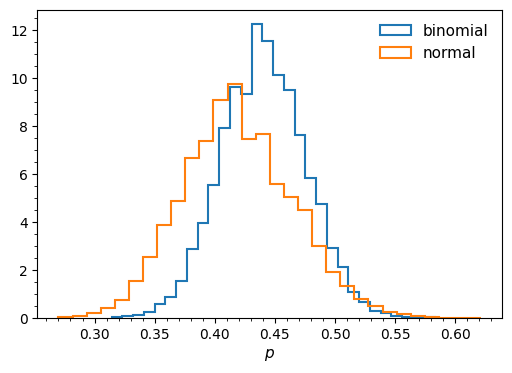

In [57]:
plt.figure(figsize=(6,4))

plt.hist(samples,bins=30,histtype='step',density=True,linewidth=1.5,label='binomial')
plt.hist(samples_norm,bins=30,histtype='step',density=True,linewidth=1.5,label='normal')

plt.xlabel(r'$p$',fontsize=11)

plt.minorticks_on()

plt.legend(fontsize=11,frameon=False)

plt.show()

In [58]:
res.logz[-1]-res_norm.logz[-1]

np.float64(6.3677694864855425)